# Data Preprocessing & Feature Engineering

This notebook prepares `final_dataset.csv` for binary default classification.

Main goals:
- inspect the data,
- review a few important distributions,
- detect outliers,
- apply targeted winsorization on financial variables,
- standardize numeric features,
- encode categorical variables in a controlled way,
- build a more realistic synthetic target (`pd_target_v2`, `default_flag_v2`),
- inject realistic contradictions (good dossiers defaulting, risky dossiers surviving),
- use a temporal split (past -> train, future -> test) instead of random split,
- save clean model-ready exports for the classification notebooks.

> Note: the **Ordered end-to-end workflow** section at the bottom is the recommended robust path for the current schema.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_style("whitegrid")

In [2]:
# Keep paths relative to the project so the notebook stays portable.
# We link directly to the new source file.
project_root = Path.cwd().parent
data_path = project_root / "data" / "final_dataset.csv"

df = pd.read_csv(data_path)

print(f"Loaded file: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded file: d:\BFPME\data\final_dataset.csv
Shape: (10000, 116)


,dossier_id,code_modele,risk_class,score_bfpme_good,score_bfpme_average,score_bfpme_global,score_bfpme_global_operational,score_bfpme_gap,SF_1,SF_2,SF_3,SF_4,SF_5,SF_6,SF_7,SF_8,SF_9,SF_10,SF_11,SF_12,SF_13,SF_14,SF_15,SF_16,SF_17,SF_18,SF_19,SF_20,SF_21,SF_22,SF_23,SF_24,SF_25,SF_26,SF_27,SF_28,SF_29,SF_30,SF_31,SF_32,SF_33,SF_34,SF_35,SF_36,SF_37,SF_38,SF_39,SF_40,SF_41,SF_42,SF_43,SF_44,SF_45,SF_46,SF_47,SF_48,SF_49,SF_50,SF_51,SF_52,SF_54,SF_55,SF_56,SF_57,SF_58,SF_59,SF_60,SF_61,SF_62,bfpme_risk_index,anciennete_entreprise,secteur_activite,region_localisation,structure_juridique,nombre_employes,classification_pme,capital_social,chiffre_affaires_annuel,zone_localisation,objectif_financement,duree_credit,type_credit,montant_total_investissement,apport_personnel,cofinancement,montant_pret,ratio_financement_externe_projet,duree_mois,type_taux,taux_interet_teg,frais_annexes,valeur_garanties,capitaux_propres,dettes_long_terme,dettes_court_terme,total_passif,fonds_roulement_fdr,besoin_fonds_roulement_bfr,tresorerie_disponible,total_actif,score_global_interne,score_financier,score_business,score_management,score_secteur_industrie,scenario_economique,retards_paiement_jours_moyen,montant_impayes,taux_inflation,taux_directeur,croissance_pib,taux_chomage,risque_sectoriel,risque_pays_region,pd_target,default_flag
0,CLI_00001,1,Rejete,0.0000,0.0000,0.0000,7.3900,0.0000,130.0000,8.0000,61.0000,41.0000,59.0000,14.0000,16.0000,22.0000,23.0000,78.0000,61.0000,83.0000,86.0000,99,27.0000,27.0000,27.0000,28.0000,61.0000,61.0000,27.0000,61.0000,27.0000,26.0000,61.0000,28.0000,27.0000,28.0000,26.0000,26.0000,27.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,103,61,61,109,115,117,121,61,0.9700,0,industrie,Centre,SA,1,micro,"347,557.8600","210,193.7600",urbaine,investissement,court_terme,court_terme,"159,602.6300","10,891.5900",1,"130,539.6500",0.8179,22,variable,15.2900,"2,053.1800","75,475.0700","62,971.4300","111,624.4800","128,583.7100","301,549.5900","-14,201.7300","5,000.0000","24,007.5900","301,549.5900",Average Financial,2.9900,0.0000,7.1400,3.2900,normal,59.2000,"23,005.6800",6.3500,7.0500,1.5000,14.1800,20.8900,22.5500,0.8894,1
1,CLI_00002,1,Rejete,0.0000,0.0000,0.0000,16.3400,0.0000,126.0000,6.0000,10.0000,57.0000,57.0000,14.0000,17.0000,21.0000,23.0000,61.0000,85.0000,84.0000,86.0000,61,26.0000,27.0000,28.0000,28.0000,28.0000,28.0000,28.0000,28.0000,61.0000,61.0000,26.0000,26.0000,27.0000,26.0000,26.0000,26.0000,28.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101,102,61,61,61,115,61,122,123,0.9700,0,agriculture,Ouest,Entreprise_individuelle,7,micro,"114,803.4100","749,161.8200",rurale,exploitation,moyen_terme,moyen_terme,"477,204.9600","64,739.5100",1,"333,885.5500",0.6997,48,fixe,13.1500,"7,412.5100","163,350.3200","301,766.2000","401,091.7800","307,654.9600","1,017,116.2300","114,269.8900","251,071.8000","1,000.0000","1,017,116.2300",Average Financial,2.3600,12.6300,0.0000,4.5200,normal,79.0000,"46,761.9000",4.9800,6.8600,1.7500,10.8300,30.5100,23.0100,0.8699,1
2,CLI_00003,2,Bon,193.2892,194.3003,193.2892,193.2892,-1.0111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0000,37.0000,7.0000,43.0000,54.0000,49.0000,51.0000,56.0000,61.0000,62.0000,67.0000,71.0000,22.0000,76.0000,18.0000,81.0000,86.0000,88.0000,91.0000,94.0000,61.0000,100,61,105,61,109,113,61,120,61,0.2200,34,commerce,Nord,SA,118,moyenne,"1,590,047.5400","19,004,900.8300",rurale,expansion,long_terme,long_terme,"9,983,970.3600","4,187,065.1400",1,"3,735,990.2100",0.3742,86,variable,4.4100,"17,167.1000","6,039,590.2700","15,512,754.8800","2,314,800.5800","4,261,005.0600","22,088,864.3300","12,777,108.3200","1,179,411.1400","3,323,045.3800","22,088,864.3300",Good Financial,69.3800,56.5200,44.9500,42.3700,normal,0.0000,"1,100.7500",4.7400,5.7700,3.0400,10.8400,33.4100,36.2700,0.0343,0
3,CLI_00004,1,Rejete,0.00

## Quick inspection

In [3]:
target_col = "default_flag"

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
})

summary.sort_values(["missing_count", "n_unique"], ascending=[False, False]).head(25)

,dtype,missing_count,missing_pct,n_unique
SF_32,float64,5604,56.0400,7
SF_41,float64,5604,56.0400,7
SF_34,float64,5604,56.0400,6
SF_35,float64,5604,56.0400,6
SF_36,float64,5604,56.0400,6
SF_38,float64,5604,56.0400,6
SF_44,float64,5604,56.0400,6
SF_45,float64,5604,56.0400,6
SF_46,float64,5604,56.0400,6
SF_33,float64,5604,56.0400,5


In [4]:
df[target_col].value_counts(dropna=False)

default_flag
1    5655
0    4345
Name: count, dtype: int64

## A few useful plots

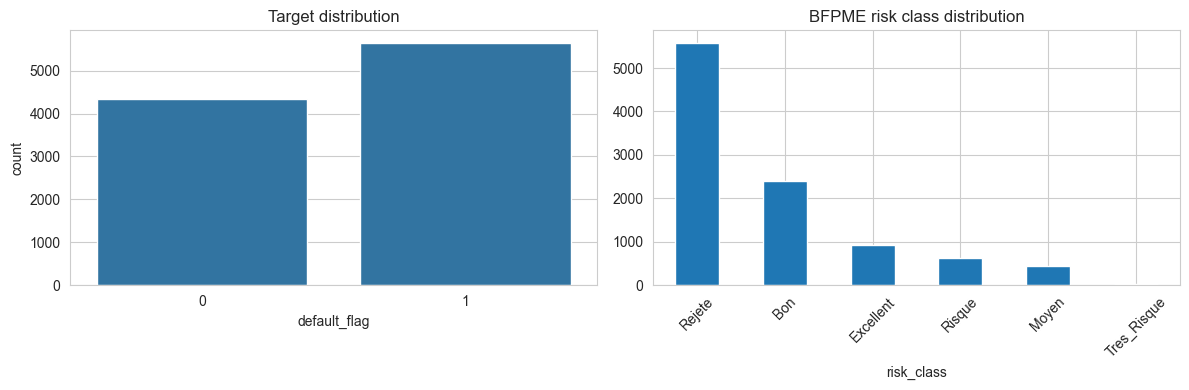

In [5]:
# We only plot a few key variables to keep the notebook readable.
# Graph 1: class balance (to check if target is skewed).
# Graph 2: BFPME risk class frequency (quick business sanity check).
plot_cols = [
    "score_bfpme_global_operational",
    "retards_paiement_jours_moyen",
    "fonds_roulement_fdr",
    "valeur_garanties",
    "ratio_financement_externe_projet",
    "pd_target"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=target_col, ax=axes[0])
axes[0].set_title("Target distribution")

df["risk_class"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("BFPME risk class distribution")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

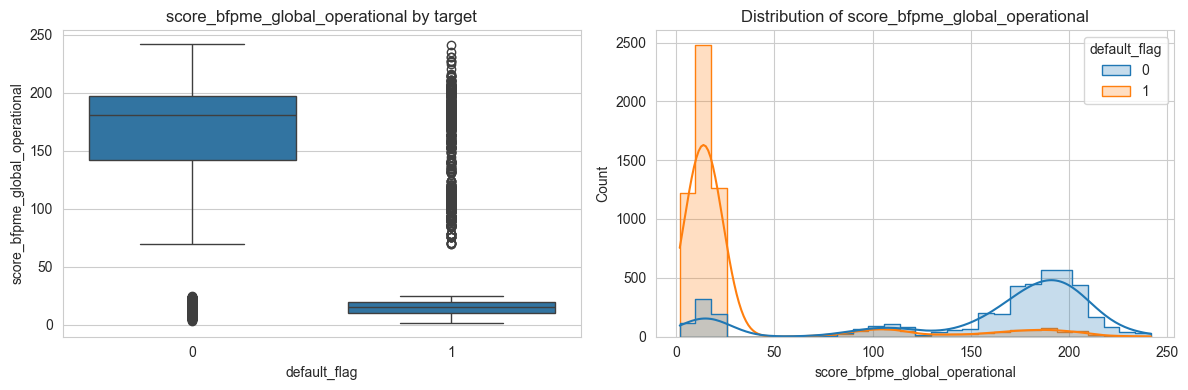

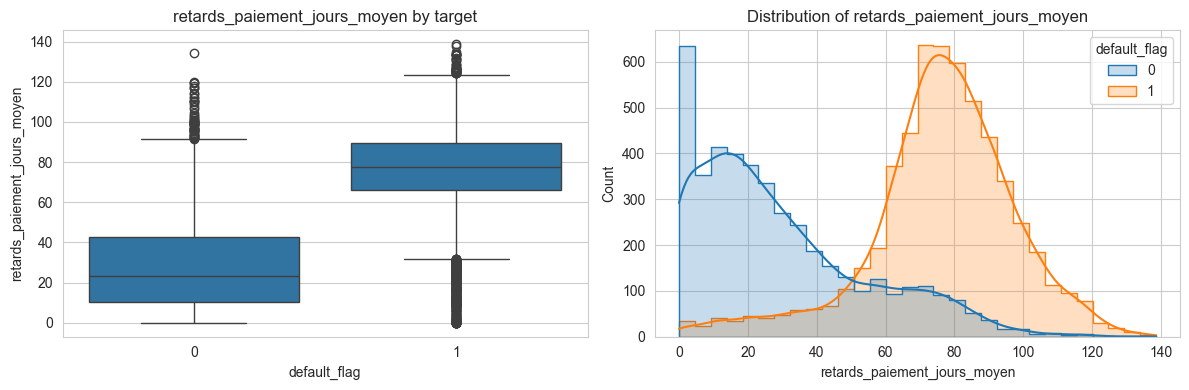

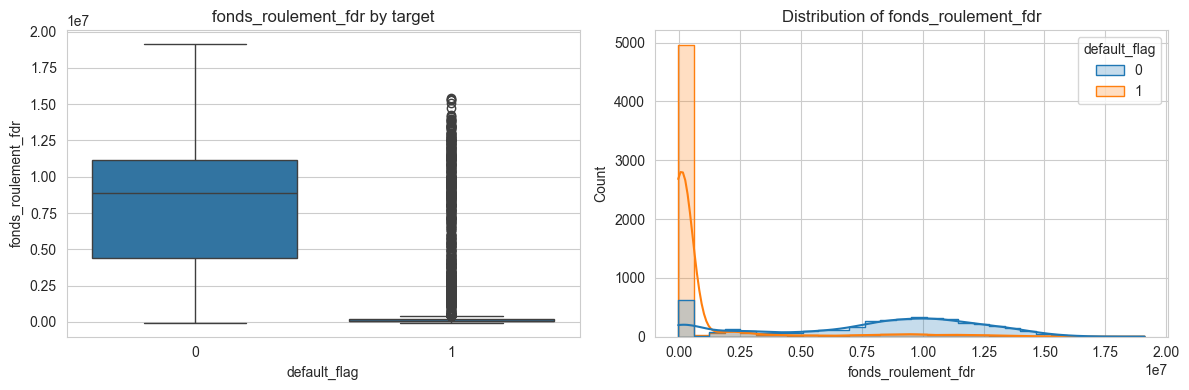

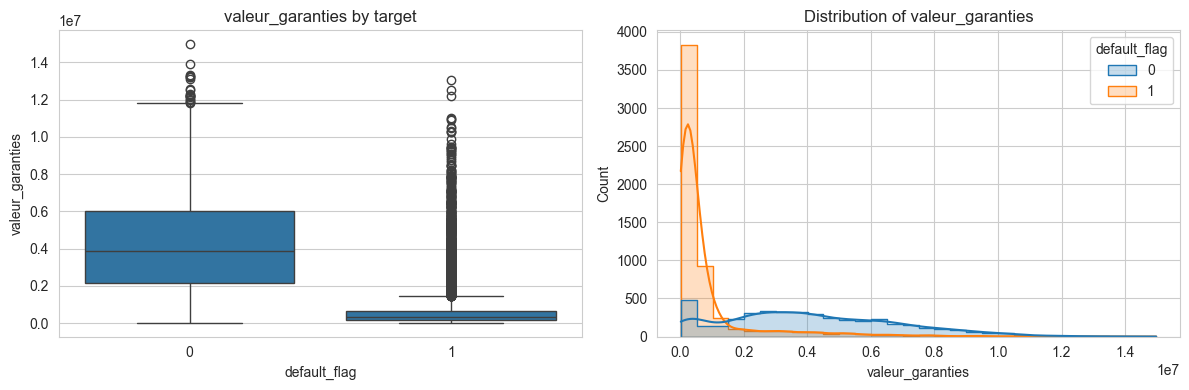

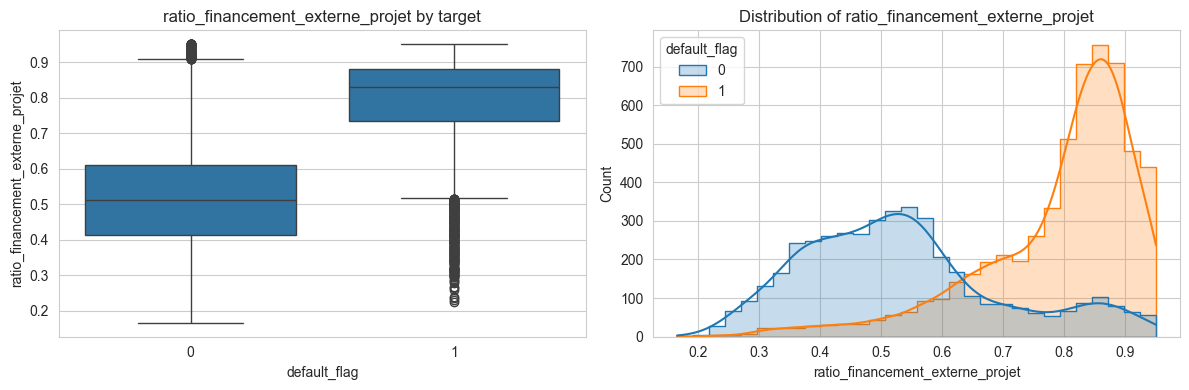

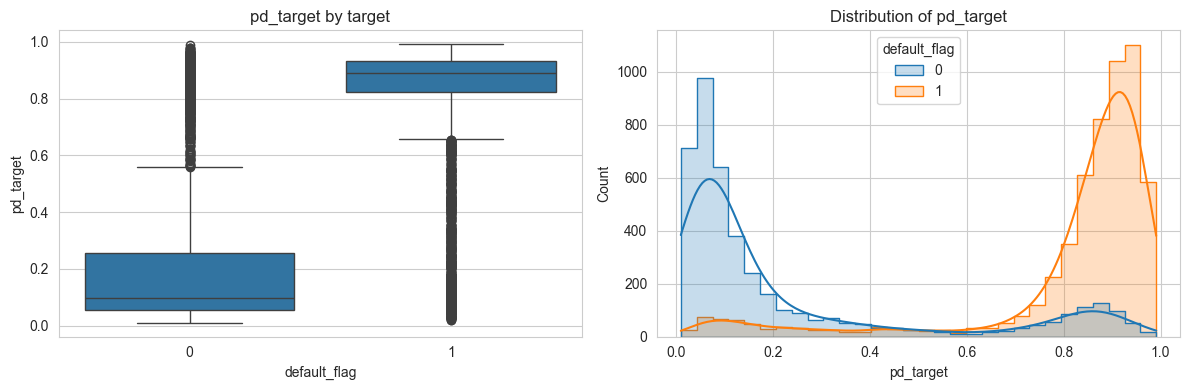

In [6]:
for col in plot_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[0])
    axes[0].set_title(f"{col} by target")

    sns.histplot(data=df, x=col, hue=target_col, kde=True, bins=30, ax=axes[1], element="step")
    axes[1].set_title(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

## Outlier review

In [7]:
def outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        rows.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(mask.sum()),
            "outlier_pct": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

outlier_report = outlier_summary(df, plot_cols)
outlier_report

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
3,valeur_garanties,"237,867.5225","3,805,433.3000","3,567,565.7775","-5,113,481.1437","9,156,781.9662",215,2.1500
0,score_bfpme_global_operational,13.2100,179.3416,166.1316,-235.9874,428.5390,0,0.0000
1,retards_paiement_jours_moyen,24.8000,81.3000,56.5000,-59.9500,166.0500,0,0.0000
2,fonds_roulement_fdr,"60,962.5325","8,707,375.1700","8,646,412.6375","-12,908,656.4238","21,676,994.1263",0,0.0000
4,ratio_financement_externe_projet,0.5177,0.8516,0.3339,0.0169,1.3525,0,0.0000
5,pd_target,0.1083,0.9049,0.7966,-1.0866,2.0999,0,0.0000


## Remove leakage columns

In [8]:
# We remove identifiers and leakage-related fields.
# - `dossier_id`: technical ID
# - `pd_target`: synthetic latent probability used to generate `default_flag`
# - any post-target labels if present
leakage_cols = [
    "dossier_id",
    "pd_target",
    "statut_credit",
    "classe_risque",
    "definition_defaut",
]
existing_leakage_cols = [col for col in leakage_cols if col in df.columns]

model_df = df.drop(columns=existing_leakage_cols).copy()

print("Dropped columns:", existing_leakage_cols)
print(f"New shape: {model_df.shape}")

Dropped columns: ['dossier_id', 'pd_target']
New shape: (10000, 114)


## Business-Driven Feature Engineering

Before splitting the data, we create a few composite features that are closer to real credit analysis.

The goal is simple:
- combine raw variables into more meaningful risk signals,
- keep the features interpretable,
- avoid creating too many artificial columns.

In [9]:
# We build a few composite features that have a direct business meaning.
# These variables are easier to explain in committees than raw monetary fields.

model_df["debt_total"] = model_df["dettes_court_terme"] + model_df["dettes_long_terme"]

# Loan burden compared to company activity.
model_df["loan_to_revenue"] = model_df["montant_pret"] / model_df["chiffre_affaires_annuel"].replace(0, np.nan)

# Liquidity cushion relative to debt.
model_df["cash_to_debt"] = model_df["tresorerie_disponible"] / model_df["debt_total"].replace(0, np.nan)

# External leverage of project financing.
model_df["financement_externe_intensity"] = model_df["ratio_financement_externe_projet"]

# Payment stress relative to exposure.
model_df["impayes_to_loan"] = model_df["montant_impayes"] / model_df["montant_pret"].replace(0, np.nan)
model_df["payment_stress_index"] = (
    np.clip(model_df["retards_paiement_jours_moyen"] / 90, 0, 3)
    + np.clip(model_df["impayes_to_loan"], 0, 3)
)

# Financial pressure index from working capital pressure.
model_df["fdr_bfr_pressure"] = model_df["besoin_fonds_roulement_bfr"] / model_df["fonds_roulement_fdr"].replace(0, np.nan)

# Coverage adequacy: guarantees vs loan.
model_df["garantie_to_loan"] = model_df["valeur_garanties"] / model_df["montant_pret"].replace(0, np.nan)

# Clean infinities that can appear after ratio creation.
model_df = model_df.replace([np.inf, -np.inf], np.nan)

new_business_features = [
    "debt_total",
    "loan_to_revenue",
    "cash_to_debt",
    "financement_externe_intensity",
    "impayes_to_loan",
    "payment_stress_index",
    "fdr_bfr_pressure",
    "garantie_to_loan",
]

model_df[new_business_features].head()

,debt_total,loan_to_revenue,cash_to_debt,financement_externe_intensity,impayes_to_loan,payment_stress_index,fdr_bfr_pressure,garantie_to_loan
0,"240,208.1900",0.6210,0.0999,0.8179,0.1762,0.8340,-0.3521,0.5782
1,"708,746.7400",0.4457,0.0014,0.6997,0.1401,1.0178,2.1972,0.4892
2,"6,575,805.6400",0.1966,0.5053,0.3742,0.0003,0.0003,0.0923,1.6166
3,"2,167,799.4000",0.4857,0.0528,0.8643,0.1455,1.0944,3.0195,0.7427
4,"5,151,833.1100",0.1219,0.5594,0.5731,0.0021,0.0988,0.1317,1.5375


## Correlation Review

We do not need a giant heatmap on every column. A focused correlation review is more useful here.

We look at:
- a few core BFPME variables,
- payment behavior,
- liquidity and leverage,
- the new engineered features.

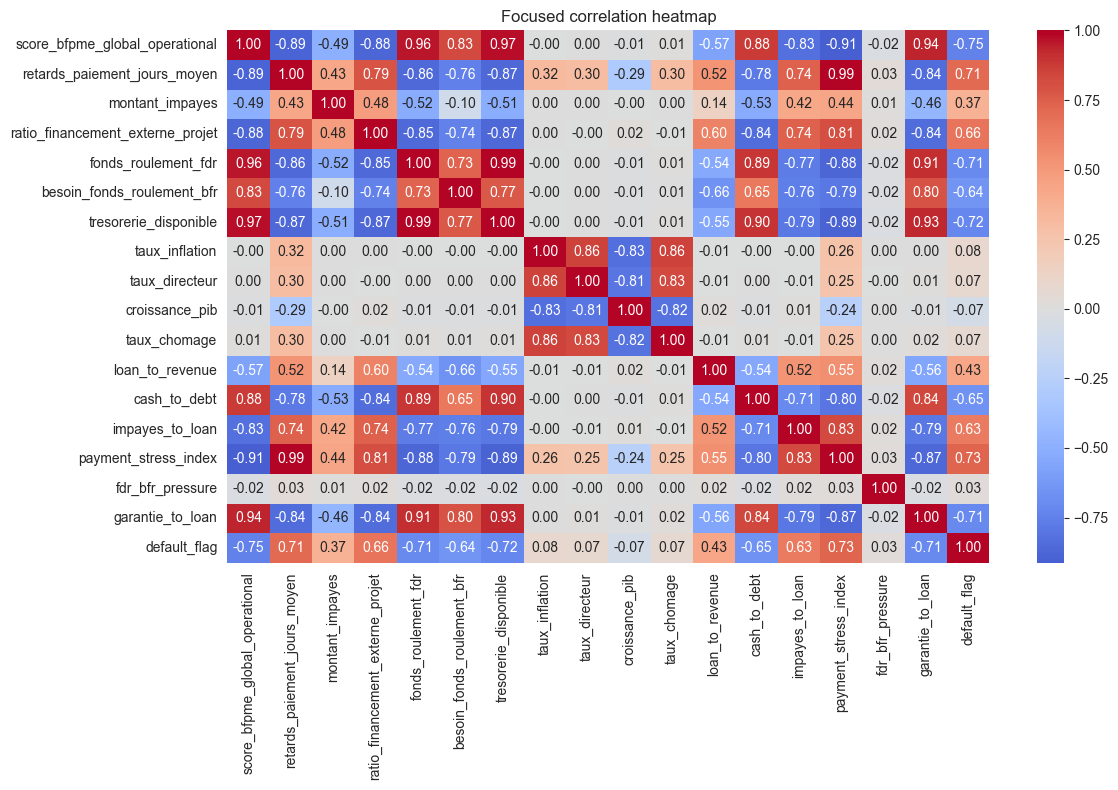

,corr_with_default_flag
score_bfpme_global_operational,-0.7461
payment_stress_index,0.7263
tresorerie_disponible,-0.7204
retards_paiement_jours_moyen,0.7114
garantie_to_loan,-0.7107
fonds_roulement_fdr,-0.7055
ratio_financement_externe_projet,0.6639
cash_to_debt,-0.6526
besoin_fonds_roulement_bfr,-0.6443
impayes_to_loan,0.6340


In [10]:
correlation_cols = [
    "score_bfpme_global_operational",
    "retards_paiement_jours_moyen",
    "montant_impayes",
    "ratio_financement_externe_projet",
    "fonds_roulement_fdr",
    "besoin_fonds_roulement_bfr",
    "tresorerie_disponible",
    "taux_inflation",
    "taux_directeur",
    "croissance_pib",
    "taux_chomage",
    "loan_to_revenue",
    "cash_to_debt",
    "impayes_to_loan",
    "payment_stress_index",
    "fdr_bfr_pressure",
    "garantie_to_loan",
    target_col,
]

correlation_cols = [col for col in correlation_cols if col in model_df.columns]
correlation_matrix = model_df[correlation_cols].corr(numeric_only=True)

# Heatmap interpretation:
# - strong red/blue cells indicate variables moving together/oppositely
# - the target column helps us spot potentially predictive features early
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Focused correlation heatmap")
plt.tight_layout()
plt.show()

correlation_with_target = (
    correlation_matrix[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_default_flag")
)

correlation_with_target

In [11]:
# This table helps us spot variables that may be telling almost the same story.
# We do not drop them automatically here. We just flag them for review.

corr_pairs = correlation_matrix.abs().unstack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]
corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

corr_pairs[corr_pairs["abs_corr"] >= 0.80].head(15)

,feature_1,feature_2,abs_corr
78,fonds_roulement_fdr,tresorerie_disponible,0.9944
253,payment_stress_index,retards_paiement_jours_moyen,0.9902
6,score_bfpme_global_operational,tresorerie_disponible,0.9718
72,fonds_roulement_fdr,score_bfpme_global_operational,0.9568
288,garantie_to_loan,score_bfpme_global_operational,0.9400
294,garantie_to_loan,tresorerie_disponible,0.9256
252,payment_stress_index,score_bfpme_global_operational,0.9124
88,fonds_roulement_fdr,garantie_to_loan,0.9116
222,cash_to_debt,tresorerie_disponible,0.8957
258,payment_stress_index,tresorerie_disponible,0.8925


## Split features and target

In [12]:
X = model_df.drop(columns=[target_col])
y = model_df[target_col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 121)
y shape: (10000,)


## Train / test split

In [13]:
# We split before preprocessing so all learned transformations come from train only.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train shape: (8000, 121)
Test shape: (2000, 121)

Train target distribution:
default_flag
1   0.5655
0   0.4345
Name: proportion, dtype: float64

Test target distribution:
default_flag
1   0.5655
0   0.4345
Name: proportion, dtype: float64


## Feature groups

In [14]:
# We use a lighter encoding strategy:
# - ordinal encoding for ordered categories
# - one-hot only for nominal categories

ordinal_map = {
    "duree_credit": ["court_terme", "moyen_terme", "long_terme"],
    "score_global_interne": ["Average Financial", "Good Financial"],
    "classe_risque": ["faible", "moyen", "eleve"],
}

ordinal_features = [c for c in ordinal_map if c in X_train.columns]
ordinal_categories = [ordinal_map[c] for c in ordinal_features]

nominal_features = [
    "risk_class",
    "secteur_activite",
    "region_localisation",
    "structure_juridique",
    "classification_pme",
    "zone_localisation",
    "type_credit",
    "objectif_financement",
    "type_taux",
    "scenario_economique",
]

nominal_features = [col for col in nominal_features if col in X_train.columns]

numeric_features = [
    col for col in X_train.select_dtypes(include=[np.number]).columns
    if col not in ordinal_features
]

print(f"Numeric features: {len(numeric_features)}")
print(f"Ordinal categorical features: {len(ordinal_features)}")
print(f"Nominal categorical features: {len(nominal_features)}")

Numeric features: 109
Ordinal categorical features: 2
Nominal categorical features: 10


## Winsorization on selected financial variables

In [15]:
# We only winsorize a focused list of columns that can have extreme financial values.
# This reduces the impact of extreme synthetic outliers without deleting clients.
winsor_cols = [
    "montant_pret",
    "montant_total_investissement",
    "valeur_garanties",
    "chiffre_affaires_annuel",
    "total_actif",
    "total_passif",
    "capitaux_propres",
    "dettes_court_terme",
    "dettes_long_terme",
    "fonds_roulement_fdr",
    "besoin_fonds_roulement_bfr",
    "tresorerie_disponible",
    "montant_impayes",
    "loan_to_revenue",
    "cash_to_debt",
    "impayes_to_loan",
    "fdr_bfr_pressure",
    "garantie_to_loan",
]
winsor_cols = [col for col in winsor_cols if col in X_train.columns]
winsor_cols

['montant_pret',
 'montant_total_investissement',
 'valeur_garanties',
 'chiffre_affaires_annuel',
 'total_actif',
 'total_passif',
 'capitaux_propres',
 'dettes_court_terme',
 'dettes_long_terme',
 'fonds_roulement_fdr',
 'besoin_fonds_roulement_bfr',
 'tresorerie_disponible',
 'montant_impayes',
 'loan_to_revenue',
 'cash_to_debt',
 'impayes_to_loan',
 'fdr_bfr_pressure',
 'garantie_to_loan']

In [16]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.lower_bounds_ = X.quantile(self.lower_quantile)
        self.upper_bounds_ = X.quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X.clip(self.lower_bounds_, self.upper_bounds_, axis=1).values


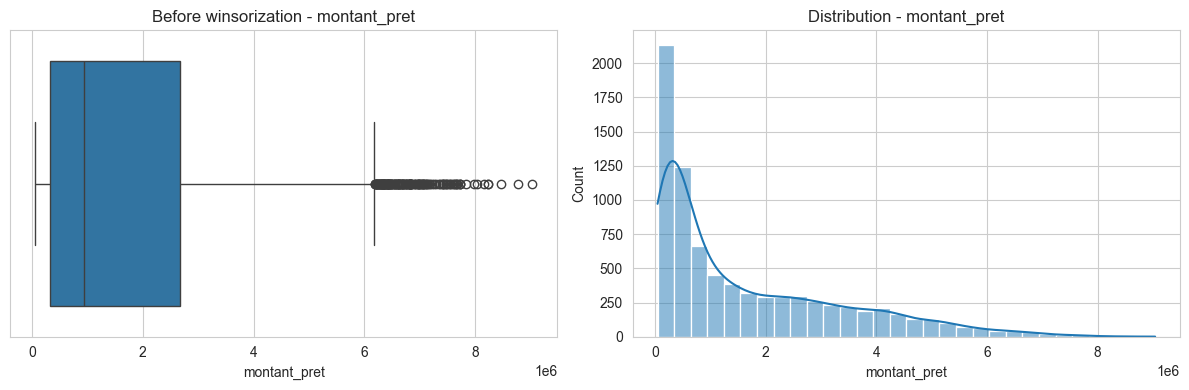

In [17]:
# Quick visual check before winsorization for a few columns.
preview_cols = [col for col in ["montant_pret", "cashflow_cumule", "debt_to_equity_ratio", "dscr"] if col in X_train.columns]

for col in preview_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=X_train[col], ax=axes[0])
    axes[0].set_title(f"Before winsorization - {col}")
    sns.histplot(X_train[col], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"Distribution - {col}")
    plt.tight_layout()
    plt.show()

## Preprocessing pipelines

In [18]:
winsor_numeric_features = [col for col in winsor_cols if col in numeric_features]
plain_numeric_features = [col for col in numeric_features if col not in winsor_numeric_features]

winsor_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer(lower_quantile=0.01, upper_quantile=0.99)),
    ("scaler", StandardScaler())
])

plain_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1))
])

# We keep one-hot only for nominal categories.
# This creates extra columns only inside the pipeline, not inside the CSV file.
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("winsor_num", winsor_numeric_transformer, winsor_numeric_features),
    ("plain_num", plain_numeric_transformer, plain_numeric_features),
    ("ord", ordinal_transformer, ordinal_features),
    ("nom", nominal_transformer, nominal_features)
])

preprocessor

,transformers,"[('winsor_num', ...), ('plain_num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Fit preprocessing and transform

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (8000, 149)
Processed test shape: (2000, 149)


In [20]:
nominal_feature_names = preprocessor.named_transformers_["nom"] \
    .named_steps["encoder"] \
    .get_feature_names_out(nominal_features) \
    .tolist()

all_feature_names = winsor_numeric_features + plain_numeric_features + ordinal_features + nominal_feature_names

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

X_train_processed_df.head()

,montant_pret,montant_total_investissement,valeur_garanties,chiffre_affaires_annuel,total_actif,total_passif,capitaux_propres,dettes_court_terme,dettes_long_terme,fonds_roulement_fdr,besoin_fonds_roulement_bfr,tresorerie_disponible,montant_impayes,loan_to_revenue,cash_to_debt,impayes_to_loan,fdr_bfr_pressure,garantie_to_loan,code_modele,score_bfpme_good,score_bfpme_average,score_bfpme_global,score_bfpme_global_operational,score_bfpme_gap,SF_1,SF_2,SF_3,SF_4,SF_5,SF_6,SF_7,SF_8,SF_9,SF_10,SF_11,SF_12,SF_13,SF_14,SF_15,SF_16,SF_17,SF_18,SF_19,SF_20,SF_21,SF_22,SF_23,SF_24,SF_25,SF_26,SF_27,SF_28,SF_29,SF_30,SF_31,SF_32,SF_33,SF_34,SF_35,SF_36,SF_37,SF_38,SF_39,SF_40,SF_41,SF_42,SF_43,SF_44,SF_45,SF_46,SF_47,SF_48,SF_49,SF_50,SF_51,SF_52,SF_54,SF_55,SF_56,SF_57,SF_58,SF_59,SF_60,SF_61,SF_62,bfpme_risk_index,anciennete_entreprise,nombre_employes,capital_social,apport_personnel,cofinancement,ratio_financement_externe_projet,duree_mois,taux_interet_teg,frais_annexes,score_financier,score_business,score_management,score_secteur_industrie,retards_paiement_jours_moyen,taux_inflation,taux_directeur,croissance_pib,taux_chomage,risque_sectoriel,risque_pays_region,debt_total,financement_externe_intensity,payment_stress_index,duree_credit,score_global_interne,risk_class_Bon,risk_class_Excellent,risk_class_Moyen,risk_class_Rejete,risk_class_Risque,risk_class_Tres_Risque,secteur_activite_agriculture,secteur_activite_btp,secteur_activite_commerce,secteur_activite_industrie,secteur_activite_services,secteur_activite_tourisme,region_localisation_Centre,region_localisation_Est,region_localisation_Littoral,region_localisation_Nord,region_localisation_Ouest,region_localisation_Sud,structure_juridique_Entreprise_individuelle,structure_juridique_SA,structure_juridique_SARL,classification_pme_micro,classification_pme_moyenne,classification_pme_petite,zone_localisation_industrielle,zone_localisation_rurale,zone_localisation_urbaine,type_credit_court_terme,type_credit_long_terme,type_credit_moyen_terme,objectif_financement_expansion,objectif_financement_exploitation,objectif_financement_investissement,type_taux_fixe,type_taux_variable,scenario_economique_degrade,scenario_economique_normal,scenario_economique_severe
4262,1.8007,2.3747,1.6405,1.5384,1.7737,1.7737,1.7269,1.6181,1.6679,1.8172,0.9866,1.6341,-0.9797,-0.5338,0.8356,-1.0895,-0.3812,0.9098,1.1348,1.7953,1.7149,1.7953,1.8435,1.4603,0.3416,-0.3316,-0.4778,0.1172,0.0134,0.3283,-0.3932,-0.1983,-0.4723,0.1935,0.3220,0.3022,0.3134,0.6194,-0.4108,-0.4172,-0.4232,-0.3858,-0.4228,-0.3999,-0.3712,-0.4584,-0.3523,-0.3397,-0.3724,-0.3952,-0.4176,-0.3770,-0.3661,-0.3493,-0.4502,-0.3987,-0.0979,-0.3670,2.0646,-1.8063,-0.2786,-0.1150,0.3299,-1.1286,0.5686,0.7592,0.0896,-0.2748,0.7471,-2.3232,0.3114,0.2805,0.5471,0.3779,-2.3442,0.3678,0.6637,0.7542,-1.0062,-1.1091,0.6352,0.5765,0.4399,-1.7685,-1.6805,-1.6073,1.9856,1.4760,1.2574,2.2917,1.4054,-1.4723,-1.7699,-1.2968,0.6198,1.8158,1.4960,1.8689,1.9807,-1.7108,-0.8968,0.0604,0.3336,-0.7572,-0.0250,-0.5767,1.6918,-1.4723,-1.6506,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
2059,-0.9341,-0.8585,-0.8309,-0.9684,-0.9747,-0.9747,-0.8731,-1.0528,-1.0574,-0.7868,-1.3108,-0.8124,-0.5150,2.5234,-0.1178,2.3428,0.4014,-1.1663,-0.8812,-0.8533,-0.8626,-0.8533,-0.8560,0.0052,0.4192,-0.3316,-0.4778,0.1172,0.9972,0.6534,-0.4571,-0.1245,-0.4723,1.0649,-2.7169,0.3022,0.3134,0.4781,-0.4943,2.3748,-0.4232,-0.4732,-0.4228,-0.3149,2.4192,2.0865,-0.3523,2.6094,2.4119,-0.3952,2.3936,-0.4609,-0.4517,-0.5244,-0.5281,-0.2631,-0.2525,0.0115,-0.3772,0.0965,-0.2786,-0.1150,0.3299,-0.0601,-0.1591,0.3203,0.0896,-0.1903,0.2059,0.4525,0.3114,0.2805,0.3026,0.3779,0.3969,0.3678,0.5511,-1.6368,0.9912,0.8988,0.5420,0.5765,0.5712,-1.7685,0.5599,0.8280,-0.4532,-1.0538,-0.

## Small post-winsorization check

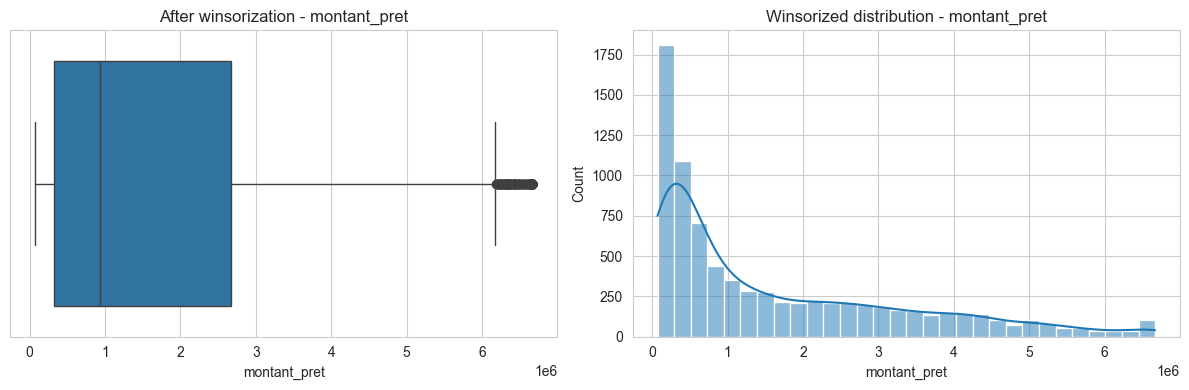

In [21]:
# This is just a quick sanity check on a few columns after clipping.
winsorizer = Winsorizer(lower_quantile=0.01, upper_quantile=0.99)
winsorized_preview = pd.DataFrame(
    winsorizer.fit_transform(X_train[winsor_cols]),
    columns=winsor_cols,
    index=X_train.index
)

for col in preview_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=winsorized_preview[col], ax=axes[0])
    axes[0].set_title(f"After winsorization - {col}")
    sns.histplot(winsorized_preview[col], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"Winsorized distribution - {col}")
    plt.tight_layout()
    plt.show()

## Quick business check against the target

In [22]:
important_cols = [
    "score_bfpme_global_operational",
    "retards_paiement_jours_moyen",
    "montant_impayes",
    "ratio_financement_externe_projet",
    "fonds_roulement_fdr",
    "tresorerie_disponible",
    "loan_to_revenue",
    "cash_to_debt",
    "payment_stress_index",
    "garantie_to_loan",
]

# This table is a quick human-readable diagnostic:
# if class 1 is clearly more stressed, the synthetic target is coherent.
available_important_cols = [col for col in important_cols if col in model_df.columns]
model_df.groupby(target_col)[available_important_cols].mean().T

default_flag,0,1
score_bfpme_global_operational,155.0161,30.3150
retards_paiement_jours_moyen,29.3561,76.1877
montant_impayes,"30,444.2345","71,911.2328"
ratio_financement_externe_projet,0.5319,0.7916
fonds_roulement_fdr,"7,822,058.7626","851,396.1410"
tresorerie_disponible,"2,216,696.9687","273,223.9825"
loan_to_revenue,0.2526,0.4829
cash_to_debt,0.3913,0.0899
payment_stress_index,0.3566,0.9930
garantie_to_loan,1.3551,0.8196


## Save ready-to-use files

In [23]:
processed_dir = project_root / "data"

X_train_processed_df.to_csv(processed_dir / "X_train_preprocessed.csv", index=False)
X_test_processed_df.to_csv(processed_dir / "X_test_preprocessed.csv", index=False)
y_train.to_csv(processed_dir / "y_train_classification.csv", index=False)
y_test.to_csv(processed_dir / "y_test_classification.csv", index=False)

print("Preprocessed files saved in /data")

Preprocessed files saved in /data


## Final note

This notebook now includes:
- a few visual checks,
- outlier review,
- targeted winsorization,
- standardization,
- lighter categorical encoding,
- reusable train/test exports.

Next step: build the classification notebook on top of these exported files.

## Making the synthetic target more realistic

In this section, we improve the target-generation logic to better simulate real credit behavior.

We apply four changes:
1. add more stochasticity/noise,
2. reduce the dominance of top predictors (`score_bfpme_global`, `dpd`),
3. inject realistic contradictions,
4. move from random split to temporal split.

In [24]:
# We start from a fresh copy of the original dataset.
# This keeps the previous sections reproducible and untouched.

df_realism = df.copy()

# Create a synthetic decision date to enable temporal split.
# Here we spread dossiers over ~4 years.
rng_local = np.random.default_rng(2026)
base_date = pd.Timestamp("2020-01-01")
df_realism["decision_date"] = base_date + pd.to_timedelta(rng_local.integers(0, 1460, len(df_realism)), unit="D")

# Build helper normalized signals (bounded in [0,1])
score_norm = np.clip(df_realism["score_bfpme_global_operational"] / 200, 0, 1)
base_risk = 1 - score_norm
dpd_risk = np.clip(df_realism["retards_paiement_jours_moyen"] / 120, 0, 1.5)
liq_protection = np.clip(df_realism["tresorerie_disponible"] / df_realism["dettes_court_terme"].replace(0, np.nan), 0, 2).fillna(0)
guarantee_protection = np.clip(df_realism["valeur_garanties"] / df_realism["montant_pret"].replace(0, np.nan), 0, 2).fillna(0)

# This index captures payment pressure directly from delays + unpaid balances.
stress_index = (
    np.clip(df_realism["retards_paiement_jours_moyen"] / 90, 0, 3)
    + np.clip(df_realism["montant_impayes"] / df_realism["montant_pret"].replace(0, np.nan), 0, 3).fillna(0)
)

In [25]:
# 1) Add more stochasticity
# 2) Reduce weight of dominant variables by spreading influence.

macro_risk = np.clip((df_realism["risque_pays_region"] + df_realism["risque_sectoriel"]) / 200, 0, 1)
leverage_risk = np.clip(df_realism["ratio_financement_externe_projet"] / 0.8, 0, 1.5)
liquidity_stress = np.clip(
    df_realism["besoin_fonds_roulement_bfr"] / df_realism["fonds_roulement_fdr"].replace(0, np.nan),
    -2,
    4,
).fillna(0)

# Stronger random component than before
noise = rng_local.normal(0, 0.80, len(df_realism))

# Rebalanced latent formula for the new schema.
latent_score_v2 = (
    -0.9
    + 1.05 * base_risk
    + 0.85 * dpd_risk
    + 0.55 * leverage_risk
    + 0.40 * np.clip(liquidity_stress, 0, None)
    + 0.55 * macro_risk
    + 0.35 * np.clip(stress_index, 0, 3)
    - 0.60 * liq_protection
    - 0.50 * guarantee_protection
    + noise
)

pd_v2 = 1 / (1 + np.exp(-latent_score_v2))
pd_v2 = np.clip(pd_v2, 0.01, 0.99)

# Initial binary draw
default_flag_v2 = (rng_local.random(len(df_realism)) < pd_v2).astype(int)

df_realism["pd_target_v2"] = pd_v2
df_realism["default_flag_v2"] = default_flag_v2

pd.Series(default_flag_v2).value_counts(normalize=True).round(3)

1   0.6290
0   0.3710
Name: proportion, dtype: float64

In [26]:
# 3) Introduce realistic contradictions.
# We force a few counter-intuitive cases:
# - some good dossiers default
# - some risky dossiers survive

good_mask = (
    (df_realism["score_bfpme_global_operational"] >= df_realism["score_bfpme_global_operational"].quantile(0.75))
    & (df_realism["retards_paiement_jours_moyen"] <= df_realism["retards_paiement_jours_moyen"].quantile(0.25))
)

bad_mask = (
    (df_realism["score_bfpme_global_operational"] <= df_realism["score_bfpme_global_operational"].quantile(0.25))
    & (df_realism["retards_paiement_jours_moyen"] >= df_realism["retards_paiement_jours_moyen"].quantile(0.75))
)

# Flip a fraction of labels in both directions.
good_idx = df_realism[good_mask].sample(frac=0.08, random_state=2026).index
bad_idx = df_realism[bad_mask].sample(frac=0.10, random_state=2027).index

# Good -> default (rare bad surprise)
df_realism.loc[good_idx, "default_flag_v2"] = 1
# Bad -> non-default (resilience / support effect)
df_realism.loc[bad_idx, "default_flag_v2"] = 0

print("Injected contradictions:")
print("good_to_default:", len(good_idx))
print("bad_to_non_default:", len(bad_idx))
print("\nNew class balance:")
print(df_realism["default_flag_v2"].value_counts(normalize=True).round(3))

Injected contradictions:
good_to_default: 146
bad_to_non_default: 119

New class balance:
default_flag_v2
1   0.6300
0   0.3700
Name: proportion, dtype: float64


In [27]:
# 4) Temporal split instead of random split.
# Train on older dossiers, test on newer dossiers.

df_realism = df_realism.sort_values("decision_date").reset_index(drop=True)

cutoff = df_realism["decision_date"].quantile(0.80)
train_temporal = df_realism[df_realism["decision_date"] <= cutoff].copy()
test_temporal = df_realism[df_realism["decision_date"] > cutoff].copy()

print("Cutoff date:", cutoff.date())
print("Train temporal shape:", train_temporal.shape)
print("Test temporal shape:", test_temporal.shape)

print("\nTarget rate (train):", train_temporal["default_flag_v2"].mean().round(3))
print("Target rate (test):", test_temporal["default_flag_v2"].mean().round(3))

Cutoff date: 2023-03-14
Train temporal shape: (8003, 119)
Test temporal shape: (1997, 119)

Target rate (train): 0.633
Target rate (test): 0.618


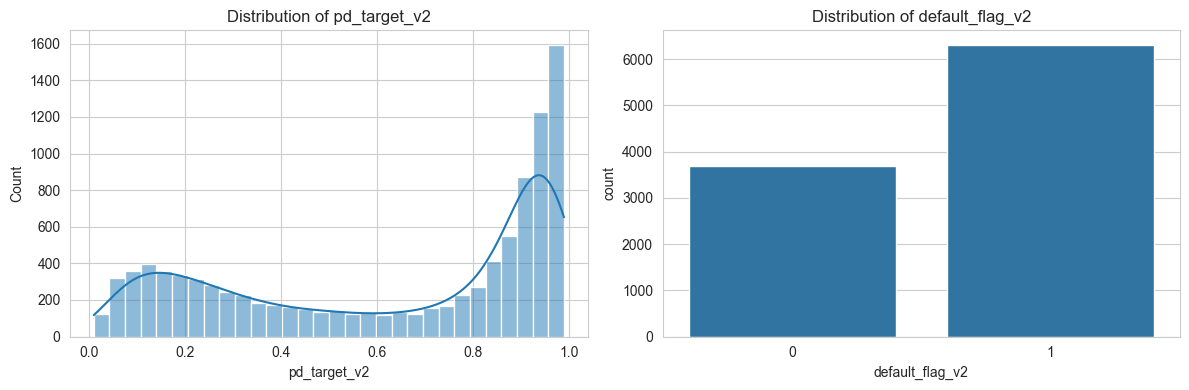

default_flag_v2                     1.0000
score_bfpme_global_operational     -0.5909
tresorerie_disponible              -0.5786
retards_paiement_jours_moyen        0.5437
ratio_financement_externe_projet    0.5335
valeur_garanties                   -0.4731
montant_impayes                     0.3351
Name: default_flag_v2, dtype: float64

In [28]:
# Quick visual checks for the improved target.
# Left graph: smooth PD distribution after realism adjustments.
# Right graph: binary class balance after label perturbations.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_realism["pd_target_v2"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of pd_target_v2")

sns.countplot(x=df_realism["default_flag_v2"], ax=axes[1])
axes[1].set_title("Distribution of default_flag_v2")

plt.tight_layout()
plt.show()

# Relationship check with key drivers after rebalancing.
check_cols = [
    "score_bfpme_global_operational",
    "retards_paiement_jours_moyen",
    "montant_impayes",
    "ratio_financement_externe_projet",
    "tresorerie_disponible",
    "valeur_garanties",
    "default_flag_v2",
]
check_cols = [c for c in check_cols if c in df_realism.columns]
corr_check = df_realism[check_cols].corr(numeric_only=True)["default_flag_v2"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_check

## Export reusable train/test files for the realistic target (v2)

This export block uses:
- `default_flag_v2` as the training target,
- temporal split (`train_temporal` / `test_temporal`),
- safe feature drop to avoid leakage.

In [29]:
# Reusable exports for model training with the realistic synthetic target.

processed_dir = project_root / "data"

# Columns to exclude from model inputs to prevent leakage.
leakage_v2_cols = [
    "dossier_id",
    "default_flag",      # old target
    "default_flag_v2",   # new target (must not be in X)
    "pd_target",         # old intermediate probability
    "pd_target_v2",      # new intermediate probability
    "decision_date",     # used for temporal split, not as predictor
    "statut_credit",
    "classe_risque",
    "definition_defaut",
]

available_leakage_v2_cols = [c for c in leakage_v2_cols if c in train_temporal.columns]

X_train_temporal_v2 = train_temporal.drop(columns=available_leakage_v2_cols).copy()
y_train_temporal_v2 = train_temporal["default_flag_v2"].astype(int).copy()

X_test_temporal_v2 = test_temporal.drop(columns=available_leakage_v2_cols).copy()
y_test_temporal_v2 = test_temporal["default_flag_v2"].astype(int).copy()

# Optional: keep a full v2 dataset snapshot for traceability.
df_realism.to_csv(processed_dir / "final_dataset_realism_v2.csv", index=False)

# Core exports for training and evaluation.
X_train_temporal_v2.to_csv(processed_dir / "X_train_temporal_v2.csv", index=False)
X_test_temporal_v2.to_csv(processed_dir / "X_test_temporal_v2.csv", index=False)
y_train_temporal_v2.to_csv(processed_dir / "y_train_temporal_v2.csv", index=False)
y_test_temporal_v2.to_csv(processed_dir / "y_test_temporal_v2.csv", index=False)

print("Saved files:")
print("- final_dataset_realism_v2.csv")
print("- X_train_temporal_v2.csv")
print("- X_test_temporal_v2.csv")
print("- y_train_temporal_v2.csv")
print("- y_test_temporal_v2.csv")

print("\nShapes:")
print("X_train_temporal_v2:", X_train_temporal_v2.shape)
print("X_test_temporal_v2:", X_test_temporal_v2.shape)
print("y_train_temporal_v2:", y_train_temporal_v2.shape)
print("y_test_temporal_v2:", y_test_temporal_v2.shape)

print("\nClass balance (train):")
print(y_train_temporal_v2.value_counts(normalize=True).round(3))
print("\nClass balance (test):")
print(y_test_temporal_v2.value_counts(normalize=True).round(3))

Saved files:
- final_dataset_realism_v2.csv
- X_train_temporal_v2.csv
- X_test_temporal_v2.csv
- y_train_temporal_v2.csv
- y_test_temporal_v2.csv

Shapes:
X_train_temporal_v2: (8003, 113)
X_test_temporal_v2: (1997, 113)
y_train_temporal_v2: (8003,)
y_test_temporal_v2: (1997,)

Class balance (train):
default_flag_v2
1   0.6330
0   0.3670
Name: proportion, dtype: float64

Class balance (test):
default_flag_v2
1   0.6180
0   0.3820
Name: proportion, dtype: float64


## Ordered end-to-end workflow (recommended)

This section re-runs the process in the clean order:
1. Load data
2. Create engineered features
3. Apply realism modifications (`pd_target_v2`, `default_flag_v2`, contradictions)
4. Define final modeling target
5. Temporal split
6. Fit preprocessing on train only
7. Export model-ready files

This keeps the same preprocessing logic used earlier (winsorization + scaling + controlled categorical encoding).

In [30]:
# 1) Load data

df_ord = pd.read_csv(data_path).copy()

# 2) Create engineered features (same business logic, adapted to final_dataset)
df_ord["debt_total"] = df_ord["dettes_court_terme"] + df_ord["dettes_long_terme"]
df_ord["loan_to_revenue"] = df_ord["montant_pret"] / df_ord["chiffre_affaires_annuel"].replace(0, np.nan)
df_ord["cash_to_debt"] = df_ord["tresorerie_disponible"] / df_ord["debt_total"].replace(0, np.nan)
df_ord["impayes_to_loan"] = df_ord["montant_impayes"] / df_ord["montant_pret"].replace(0, np.nan)
df_ord["fdr_bfr_pressure"] = df_ord["besoin_fonds_roulement_bfr"] / df_ord["fonds_roulement_fdr"].replace(0, np.nan)
df_ord["garantie_to_loan"] = df_ord["valeur_garanties"] / df_ord["montant_pret"].replace(0, np.nan)

df_ord["payment_stress_index"] = (
    np.clip(df_ord["retards_paiement_jours_moyen"] / 90, 0, 3)
    + np.clip(df_ord["impayes_to_loan"], 0, 3)
)

df_ord = df_ord.replace([np.inf, -np.inf], np.nan)

df_ord.shape

(10000, 123)

In [31]:
# 3) Apply realism modifications
rng_ord = np.random.default_rng(2026)

# Synthetic decision date for temporal split
base_date_ord = pd.Timestamp("2020-01-01")
df_ord["decision_date"] = base_date_ord + pd.to_timedelta(rng_ord.integers(0, 1460, len(df_ord)), unit="D")

score_norm_ord = np.clip(df_ord["score_bfpme_global_operational"] / 200, 0, 1)
base_risk_ord = 1 - score_norm_ord
dpd_risk_ord = np.clip(df_ord["retards_paiement_jours_moyen"] / 120, 0, 1.5)
liq_protection_ord = np.clip(df_ord["tresorerie_disponible"] / df_ord["dettes_court_terme"].replace(0, np.nan), 0, 2).fillna(0)
guarantee_protection_ord = np.clip(df_ord["valeur_garanties"] / df_ord["montant_pret"].replace(0, np.nan), 0, 2).fillna(0)

macro_risk_ord = np.clip((df_ord["risque_pays_region"] + df_ord["risque_sectoriel"]) / 200, 0, 1)
leverage_risk_ord = np.clip(df_ord["ratio_financement_externe_projet"] / 0.8, 0, 1.5)
liquidity_stress_ord = np.clip(df_ord["fdr_bfr_pressure"], -2, 4)

noise_ord = rng_ord.normal(0, 0.80, len(df_ord))

latent_score_v2_ord = (
    -0.9
    + 1.05 * base_risk_ord
    + 0.85 * dpd_risk_ord
    + 0.55 * leverage_risk_ord
    + 0.40 * np.clip(liquidity_stress_ord, 0, None)
    + 0.55 * macro_risk_ord
    + 0.35 * np.clip(df_ord["payment_stress_index"], 0, 3)
    - 0.60 * liq_protection_ord
    - 0.50 * guarantee_protection_ord
    + noise_ord
)

df_ord["pd_target_v2"] = np.clip(1 / (1 + np.exp(-latent_score_v2_ord)), 0.01, 0.99)
df_ord["default_flag_v2"] = (rng_ord.random(len(df_ord)) < df_ord["pd_target_v2"]).astype(int)

# Inject realistic contradictions: a few good files default, a few weak files survive.
good_mask_ord = (
    (df_ord["score_bfpme_global_operational"] >= df_ord["score_bfpme_global_operational"].quantile(0.75))
    & (df_ord["retards_paiement_jours_moyen"] <= df_ord["retards_paiement_jours_moyen"].quantile(0.25))
)
bad_mask_ord = (
    (df_ord["score_bfpme_global_operational"] <= df_ord["score_bfpme_global_operational"].quantile(0.25))
    & (df_ord["retards_paiement_jours_moyen"] >= df_ord["retards_paiement_jours_moyen"].quantile(0.75))
)

good_idx_ord = df_ord[good_mask_ord].sample(frac=0.08, random_state=2026).index
bad_idx_ord = df_ord[bad_mask_ord].sample(frac=0.10, random_state=2027).index

df_ord.loc[good_idx_ord, "default_flag_v2"] = 1
df_ord.loc[bad_idx_ord, "default_flag_v2"] = 0

print("default_flag_v2 balance:")
print(df_ord["default_flag_v2"].value_counts(normalize=True).round(3))

default_flag_v2 balance:
default_flag_v2
1   0.6300
0   0.3700
Name: proportion, dtype: float64


In [32]:
# 4) Define final modeling dataframe/target
# 5) Temporal split

model_target = "default_flag_v2"

# Remove leakage-prone columns from X
leakage_cols_ord = [
    "dossier_id",
    "default_flag",      # old target
    "default_flag_v2",   # new target
    "pd_target",         # old intermediate probability
    "pd_target_v2",      # new intermediate probability
    "decision_date"      # split helper
]

feature_cols_ord = [c for c in df_ord.columns if c not in leakage_cols_ord]

# Sort by date then split chronologically (80/20)
df_ord = df_ord.sort_values("decision_date").reset_index(drop=True)
cutoff_ord = df_ord["decision_date"].quantile(0.80)

train_ord = df_ord[df_ord["decision_date"] <= cutoff_ord].copy()
test_ord = df_ord[df_ord["decision_date"] > cutoff_ord].copy()

X_train_ord = train_ord[[c for c in feature_cols_ord if c in train_ord.columns]].copy()
X_test_ord = test_ord[[c for c in feature_cols_ord if c in test_ord.columns]].copy()
y_train_ord = train_ord[model_target].astype(int).copy()
y_test_ord = test_ord[model_target].astype(int).copy()

print("Cutoff:", cutoff_ord.date())
print("Train shape:", X_train_ord.shape, "| Test shape:", X_test_ord.shape)
print("Train target rate:", y_train_ord.mean().round(3), "| Test target rate:", y_test_ord.mean().round(3))

Cutoff: 2023-03-14
Train shape: (8003, 120) | Test shape: (1997, 120)
Train target rate: 0.633 | Test target rate: 0.618


In [33]:
# 6) Fit preprocessing only on train (same pipeline components as before)

ordinal_map_ord = {
    "duree_credit": ["court_terme", "moyen_terme", "long_terme"],
    "score_global_interne": ["Average Financial", "Good Financial"],
}
ordinal_features_ord = [c for c in ordinal_map_ord if c in X_train_ord.columns]
ordinal_categories_ord = [ordinal_map_ord[c] for c in ordinal_features_ord]

nominal_features_ord = [
    "risk_class", "secteur_activite", "region_localisation", "structure_juridique",
    "classification_pme", "zone_localisation", "type_credit", "objectif_financement",
    "type_taux", "scenario_economique"
]
nominal_features_ord = [c for c in nominal_features_ord if c in X_train_ord.columns]

numeric_features_ord = [
    c for c in X_train_ord.select_dtypes(include=[np.number]).columns
    if c not in ordinal_features_ord
]

winsor_cols_ord = [
    "montant_pret", "montant_total_investissement", "valeur_garanties", "chiffre_affaires_annuel",
    "total_actif", "total_passif", "capitaux_propres", "dettes_court_terme", "dettes_long_terme",
    "fonds_roulement_fdr", "besoin_fonds_roulement_bfr", "tresorerie_disponible", "montant_impayes",
    "loan_to_revenue", "cash_to_debt", "impayes_to_loan", "fdr_bfr_pressure", "garantie_to_loan"
]
winsor_numeric_features_ord = [c for c in winsor_cols_ord if c in numeric_features_ord]
plain_numeric_features_ord = [c for c in numeric_features_ord if c not in winsor_numeric_features_ord]

winsor_numeric_transformer_ord = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer(lower_quantile=0.01, upper_quantile=0.99)),
    ("scaler", StandardScaler())
])
plain_numeric_transformer_ord = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
ordinal_transformer_ord = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories_ord, handle_unknown="use_encoded_value", unknown_value=-1))
])
nominal_transformer_ord = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_ord = ColumnTransformer(transformers=[
    ("winsor_num", winsor_numeric_transformer_ord, winsor_numeric_features_ord),
    ("plain_num", plain_numeric_transformer_ord, plain_numeric_features_ord),
    ("ord", ordinal_transformer_ord, ordinal_features_ord),
    ("nom", nominal_transformer_ord, nominal_features_ord),
])

X_train_ord_p = preprocessor_ord.fit_transform(X_train_ord)
X_test_ord_p = preprocessor_ord.transform(X_test_ord)

print("Processed train/test shapes:", X_train_ord_p.shape, X_test_ord_p.shape)

Processed train/test shapes: (8003, 148) (1997, 148)


In [34]:
# 7) Export model-ready files (ordered workflow)

num_names_ord = winsor_numeric_features_ord + plain_numeric_features_ord
cat_ord_names = ordinal_features_ord
cat_nom_names = (
    preprocessor_ord.named_transformers_["nom"]
    .named_steps["encoder"]
    .get_feature_names_out(nominal_features_ord)
    .tolist()
)

all_feature_names_ord = num_names_ord + cat_ord_names + cat_nom_names

X_train_ord_df = pd.DataFrame(X_train_ord_p, columns=all_feature_names_ord, index=X_train_ord.index)
X_test_ord_df = pd.DataFrame(X_test_ord_p, columns=all_feature_names_ord, index=X_test_ord.index)

processed_dir = project_root / "data"
X_train_ord_df.to_csv(processed_dir / "X_train_preprocessed_final_dataset.csv", index=False)
X_test_ord_df.to_csv(processed_dir / "X_test_preprocessed_final_dataset.csv", index=False)
y_train_ord.to_csv(processed_dir / "y_train_final_dataset.csv", index=False)
y_test_ord.to_csv(processed_dir / "y_test_final_dataset.csv", index=False)

# Traceability snapshot after realism + feature engineering.
df_ord.to_csv(processed_dir / "final_dataset_preprocessed_base.csv", index=False)

print("Saved:")
print("- final_dataset_preprocessed_base.csv")
print("- X_train_preprocessed_final_dataset.csv")
print("- X_test_preprocessed_final_dataset.csv")
print("- y_train_final_dataset.csv")
print("- y_test_final_dataset.csv")

Saved:
- final_dataset_preprocessed_base.csv
- X_train_preprocessed_final_dataset.csv
- X_test_preprocessed_final_dataset.csv
- y_train_final_dataset.csv
- y_test_final_dataset.csv
